## Import Package

In [1]:
import itertools
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
!pip install scikeras

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

In [4]:
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score

## Import Data


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#Jika menggunakan format Excel Workbook, sesuaikan nama file, langsung run
df = pd.read_csv('/content/drive/MyDrive/Tugas/HEXA.csv')

# Select only the 'close' and 'date' columns
df = df[['date', 'close']]

# Memanggil data terbawah (default=5)
df.head()

,date,close
0,2019-07-29,3250.0
1,2019-07-30,3240.0
2,2019-07-31,3360.0
3,2019-08-01,3360.0
4,2019-08-02,3360.0


In [7]:
# Select only the 'close' and 'date' columns
df_clean = df[['date', 'close']]

df_clean.head()

,date,close
0,2019-07-29,3250.0
1,2019-07-30,3240.0
2,2019-07-31,3360.0
3,2019-08-01,3360.0
4,2019-08-02,3360.0


## Plot Runtun Waktu

In [8]:
# Setting indeks menjadi indeks runtun waktu
ts_df=df_clean.set_index('date')
ts_df.head()

,close
date,
2019-07-29,3250.0
2019-07-30,3240.0
2019-07-31,3360.0
2019-08-01,3360.0
2019-08-02,3360.0


Text(0.5, 1.0, 'HEXA Stock Price Time Series')

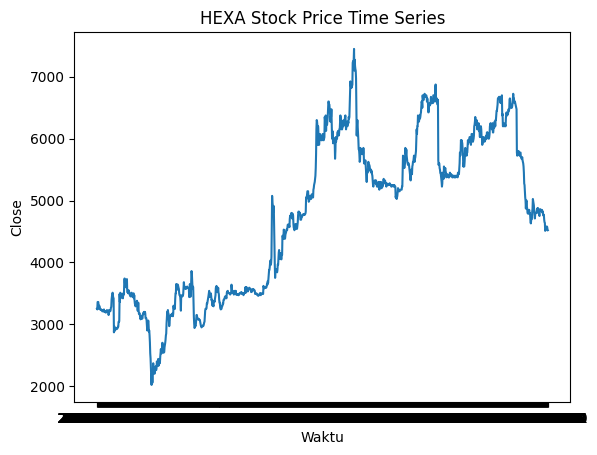

In [9]:
#Plot Time Series ini jika tidak dilakukan proses pengindeksan runtun waktu, maka variabel Y hanya berupa urutan observasi

fig = plt.figure()
plt.plot(ts_df)
plt.xlabel('Waktu')  #  mewakili timeline
plt.ylabel('Close')  #  mewakili harga saham dalam Rupiah
plt.title('HEXA Stock Price Time Series')

## Scatter Plot

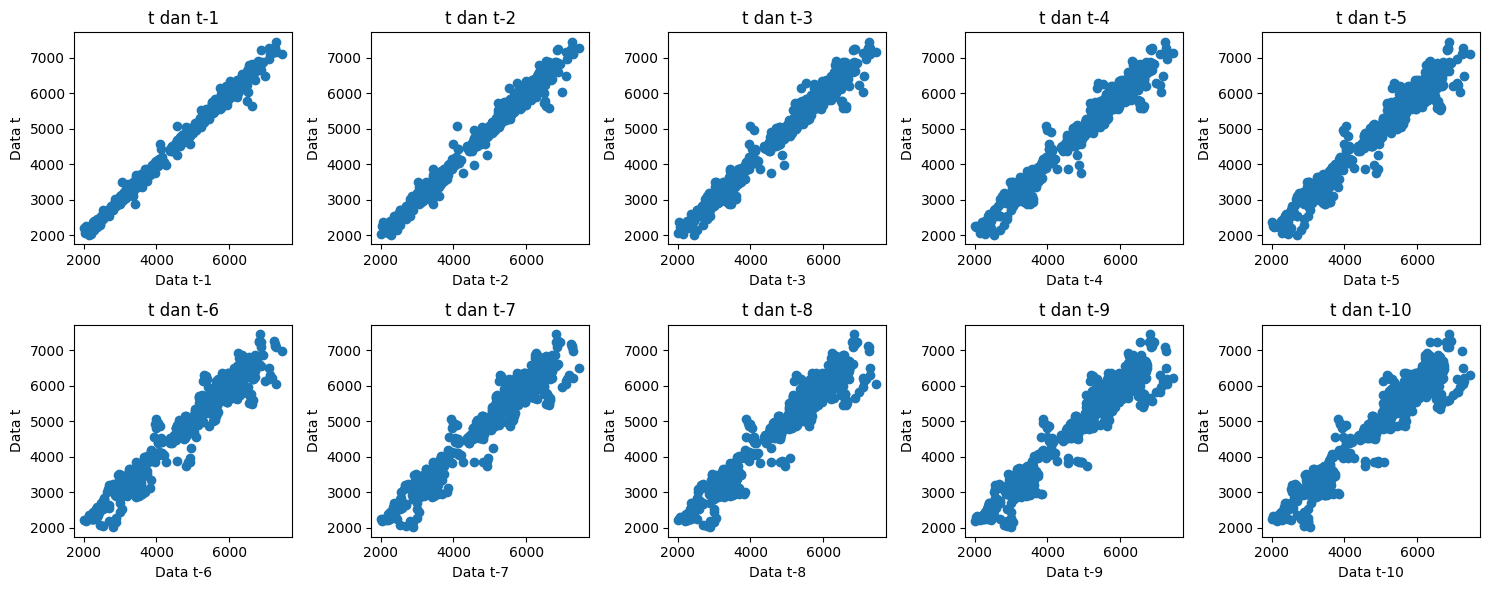

In [10]:
# Membuat scatter plot untuk t dan t-k (k dari 1 hingga 10)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))

# Flatten array 2D dari subplot menjadi 1D
axes = axes.flatten()

# Membuat scatter plot untuk t dan t-k (k dari 1 hingga 10)
for k, ax in enumerate(axes, start=1):
    # Create a temporary DataFrame for plotting current k, based on df_clean
    temp_df_for_k = df_clean.copy()

    # Membuat kolom 'data_t_minus_k' dengan data t-k
    temp_df_for_k['data_t_minus_k'] = temp_df_for_k['close'].shift(k)

    # Menghapus baris pertama yang memiliki nilai NaN untuk data_t_minus_k
    # This dropna will only affect the current 'close' and 'data_t_minus_k' columns
    temp_df_for_k = temp_df_for_k.dropna()

    # Membuat scatter plot
    ax.scatter(temp_df_for_k['data_t_minus_k'], temp_df_for_k['close'])
    ax.set_title(f't dan t-{k}')
    ax.set_xlabel(f'Data t-{k}')
    ax.set_ylabel('Data t')

# Menyesuaikan layout subplot
plt.tight_layout()

# Menampilkan plot
plt.show()

# Prepocessing Data

## Membagi data menjadi trainig dan testing

In [11]:
#Reshape agar menjadi array
df1 = df['close'].values.reshape(-1, 1)
df1

array([[3250.],
       [3240.],
       [3360.],
       ...,
       [4570.],
       [4530.],
       [4520.]])

Data training dan data testing dibagi dengan perbandingan 80:20

In [12]:
#Split data menjadi training dan testing
train_size = int(len(df1) * 0.8)
test_size = len(df1) - train_size
train, test = df1[0:train_size,:], df1[train_size:len(df1),:]
print(len(train), len(test))

1084 271


## Normalisasi Data

In [13]:
# Scalling data
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
train_scale = min_max_scaler.fit_transform(train)
min_max_scaler.fit(train)
test_scale = min_max_scaler.transform(test)

In [14]:
test_scale

array([[0.63167587],
       [0.63167587],
       [0.63167587],
       [0.62707182],
       [0.64088398],
       [0.65930018],
       [0.69152855],
       [0.68232044],
       [0.69152855],
       [0.72836096],
       [0.71915285],
       [0.72836096],
       [0.72375691],
       [0.71915285],
       [0.70073665],
       [0.68692449],
       [0.65009208],
       [0.65930018],
       [0.65009208],
       [0.65009208],
       [0.66390424],
       [0.68692449],
       [0.7053407 ],
       [0.69152855],
       [0.68692449],
       [0.69152855],
       [0.68232044],
       [0.69152855],
       [0.69152855],
       [0.70994475],
       [0.72836096],
       [0.71915285],
       [0.72375691],
       [0.72836096],
       [0.73296501],
       [0.73756906],
       [0.73756906],
       [0.73756906],
       [0.72375691],
       [0.7145488 ],
       [0.73296501],
       [0.74677716],
       [0.74677716],
       [0.74677716],
       [0.74217311],
       [0.72375691],
       [0.72836096],
       [0.732

In [15]:
# Inverse transform the scaled training and testing data to their original scale
train_original = min_max_scaler.inverse_transform(train_scale)
test_original = min_max_scaler.inverse_transform(test_scale)

print("Original Training Data (first 5 values):\n", train_original[:5])
print("\nOriginal Testing Data (first 5 values):\n", test_original[:5])

Original Training Data (first 5 values):
 [[3250.]
 [3240.]
 [3360.]
 [3360.]
 [3360.]]

Original Testing Data (first 5 values):
 [[5450.]
 [5450.]
 [5450.]
 [5425.]
 [5500.]]


In [16]:
scaling_training = pd.DataFrame(train_scale)
scaling_training.T.to_excel('scaling training.xlsx', index=False)

scaling_testing = pd.DataFrame(test_scale)
scaling_testing.T.to_excel('scaling testing.xlsx', index=False)

# Percobaan (2, 20, 0.01)


## Penetapan Random Seed

In [17]:
# Menetapkan random seed untuk reproducibility

import numpy as np
import tensorflow as tf
import random as python_random
import os

# The below is necessary for starting Numpy prior to Keras
# reproducibility.
np.random.seed(42)

# The below is necessary for starting Python prior to Keras
# reproducibility.
python_random.seed(42)

# The below is necessary for starting TensorFlow-related
# reproducibility.
os.environ['PYTHONHASHSEED'] = str(42)
tf.random.set_seed(42)

# Optional: for some older TensorFlow versions or specific operations,
# you might need to set these as well:
# from tensorflow.keras import backend as K
# K.clear_session()
# K.set_session(tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph()))

print("Random seeds have been set for reproducibility.")


Random seeds have been set for reproducibility.


## Fungsi Dataset

In [18]:
# Fungsi untuk membuat dataset dengan lookback tertentu
def create_lookback_dataset(data, lookback):
    X, y = [], []
    for i in range(len(data)-lookback):
        a = data[i:(i+lookback), 0]
        X.append(a)
        y.append(data[i + lookback, 0])
    return np.array(X), np.array(y)

## Fungsi MLP

In [19]:
def create_mlp_model(input_shape, hidden_neurons, learning_rate):
    model = Sequential()
    model.add(Dense(hidden_neurons, input_shape=(input_shape,), activation='relu'))
    model.add(Dense(1, activation='linear'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

In [20]:
def create_model_with_lookback(lookback, hidden_neurons, learning_rate):
    input_shape = lookback
    model = create_mlp_model(input_shape, hidden_neurons, learning_rate)
    return model

## Hyperparameter

In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, KFold

# Define the search space for hyperparameters
lookback_values = [1, 2, 3]
# For MLPRegressor, hidden_layer_sizes is a tuple of ints.
# This creates tuples for a single hidden layer with a varying number of neurons.
hidden_neurons_values = [(neurons,) for neurons in [7, 9, 18, 20, 21]]
learning_rate_values = [0.01, 0.02, 0.001, 0.005]

# Parameter grid for MLPRegressor
param_grid = {
    'hidden_layer_sizes': hidden_neurons_values,
    'learning_rate_init': learning_rate_values
}

# Loop to find the best combination with the smallest error
best_score = -0.000211  # For neg_mean_squared_error, higher is better
best_params = {'lookback': 2, 'hidden_neurons':20, 'learning_rate':0.01}

for lookback_value in lookback_values:
    # Create the dataset with a specific lookback
    # Assuming create_lookback_dataset is defined elsewhere
    X_train, y_train = create_lookback_dataset(train_scale, lookback_value)

    # Create the MLPRegressor model
    # Common parameters are set for consistency
    model = MLPRegressor(max_iter=100, batch_size=32, verbose=0, random_state=123)

    # Perform GridSearchCV
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(estimator=model, param_grid=param_grid,
                        scoring='neg_mean_squared_error', n_jobs=-1, cv=kf)
    grid_result = grid.fit(X_train, y_train)

    # Check if the current combination is better than the previous one
    # For neg_mean_squared_error, a higher score (closer to zero) is better.
    if grid_result.best_score_ > best_score:
        best_score = grid_result.best_score_
        best_params = {
            'lookback': lookback_value,
            'hidden_layer_sizes': grid_result.best_params_['hidden_layer_sizes'],
            'learning_rate_init': grid_result.best_params_['learning_rate_init']
        }

# Print the best tuning results
print("Best: %f using %s" % (best_score, best_params))

Best: -0.000211 using {'lookback': 2, 'hidden_neurons': 20, 'learning_rate': 0.01}


## Pelatihan Hasil Hypertuning

In [21]:
#Import library yang dibutuhkan
import tensorflow as tf
from keras.layers import Dense, Input, Dropout
from keras.optimizers import Adam
from keras.models import Model
from keras.models import load_model
from keras.callbacks import ModelCheckpoint

In [22]:
best_lookback = 2
best_hidden_neurons = 20
best_learning_rate = 0.01

X_train, y_train = create_lookback_dataset(train_scale, best_lookback)

# Membuat model dengan parameter terbaik
input_shape = best_lookback
modela = create_mlp_model(input_shape, best_hidden_neurons, best_learning_rate)

# Latih model dengan keseluruhan dataset
modela.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0629
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1150e-04
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8739e-04
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8497e-04
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8332e-04
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8112e-04
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7854e-04
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6879e-04
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5666e-04
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5746e-04
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5997e-04
Epoch 13/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6216e-04
Epoch 14/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6933e-04
Epoch 15/100
34/34 ━━━━

## Bobot dan bias

In [23]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Install xlsxwriter if not already installed
!pip install xlsxwriter

def create_lookback_dataset(data, lookback):
    X, y = [], []
    for i in range(len(data)-lookback):
        a = data[i:(i+lookback), 0]
        X.append(a)
        y.append(data[i + lookback, 0])
    return np.array(X), np.array(y)

def create_model(hidden_neurons, learning_rate, input_shape):
    model = Sequential()
    model.add(Dense(hidden_neurons, input_shape=(input_shape,), activation='relu'))
    model.add(Dense(1, activation='linear'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

best_lookback = 2
best_hidden_neurons = 20
best_learning_rate = 0.01

X_train, y_train = create_lookback_dataset(train_scale, best_lookback)

# Membuat model dengan parameter terbaik
input_shape = best_lookback
modela = create_model(best_hidden_neurons, best_learning_rate, input_shape=input_shape) # Corrected function call and argument order

# Latih model dengan keseluruhan dataset
modela.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

print("Weights and Biases of the MLP Model for (lookback=2, hidden_neurons=20, learning_rate=0.01):\n")
weights_biases_list = []
for i, layer_weights in enumerate(modela.get_weights()):
    print(f"Layer {i+1} - Shape: {layer_weights.shape}")
    print(f"Weights/Biases:\n{layer_weights}\n")
    weights_biases_list.append(layer_weights)

# Save weights and biases to an Excel file
output_filename = 'model_weights_and_biases.xlsx'
writer = pd.ExcelWriter(output_filename, engine='xlsxwriter')

for i, wb_array in enumerate(weights_biases_list):
    df_wb = pd.DataFrame(wb_array)
    if i == 0:
        sheet_name = 'Input_Layer_Weights'
    elif i == 1:
        sheet_name = 'Input_Layer_Biases'
    elif i == 2:
        sheet_name = 'Output_Layer_Weights'
    elif i == 3:
        sheet_name = 'Output_Layer_Biases'
    else:
        sheet_name = f'Layer_{i+1}_Weights_Biases'

    df_wb.to_excel(writer, sheet_name=sheet_name, index=False)

writer.close()
print(f"Weights and biases saved to {output_filename}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.6 MB/s eta 0:00:00
Weights and Biases of the MLP Model for (lookback=2, hidden_neurons=20, learning_rate=0.01):

Layer 1 - Shape: (2, 20)
Weights/Biases:
[[ 0.31280494 -0.13658309 -0.12296301 -0.32762513 -0.11031154  0.2905112
  -0.4649971  -0.10781621 -0.41661993 -0.40588292 -0.28430864  0.07291674
  -0.17504743  0.3888516  -0.3180688  -0.3199896  -0.16814078 -0.04858753
  -0.13369203 -0.02438766]
 [ 0.18271136  0.78755337 -0.3652107  -0.28012094 -0.39327827  0.6082537
   0.2060972   0.3384632   0.38730422 -0.3119874   0.17638874  0.55318344
  -0.48991165 -0.15273632  0.75266355  0.2041651   0.08391518  0.00984513
  -0.21543324 -0.2814994 ]]

Layer 2 - Shape: (20,)
Weights/Biases:
[-0.00939673 -0.01606959  0.          0.          0.         -0.0190031
 -0.05585193 -0.00568377  0.092182    0.         -0.11253867 -0.01720391
  0.         -0.06256941 -0.02611667 -0.1021404  -0.1249079  -0.11279571
  0.          0.        ]

Lay

## Evaluasi Model

## Menghitung nilai terbaik

In [ ]:
# Data testing (contoh, sesuaikan dengan data Anda)
X_test, y_test = create_lookback_dataset(test_scale, best_lookback)

In [ ]:
#Prediksi data training dan testing berdasarkan bobot terbaik yang didapat
trainPredict = modela.predict(X_train)
testPredict = modela.predict(X_test)

#Re-shape data Y train dan testing agar dapat dikonversi menjadi data asli kembali
y_tr=y_train.reshape(-1,1)
y_ts=y_test.reshape(-1,1)

#Konversi data train dan test
trainPredict=min_max_scaler.inverse_transform(trainPredict)
y_train=min_max_scaler.inverse_transform(y_tr)
testPredict=min_max_scaler.inverse_transform(testPredict)
y_test=min_max_scaler.inverse_transform(y_ts)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
# Menghitung RMSE
from sklearn import metrics

score = np.sqrt(metrics.mean_squared_error(trainPredict,y_train))
print(f"RMSE data training: {score}")
score = np.sqrt(metrics.mean_squared_error(testPredict,y_test))
print(f"RMSE data testing: {score}")

RMSE data training: 88.23606367439038
RMSE data testing: 84.4648874295886


In [ ]:
# Menghitung MAPE
mape1 = np.mean(np.abs((y_train - trainPredict)/y_train))*100
print(f"MAPE data training: {mape1}")
mape2 = np.mean(np.abs((y_test - testPredict)/y_test))*100
print(f"MAPE data testing: {mape2}")

MAPE data training: 1.262479638584368
MAPE data testing: 1.008782106550909


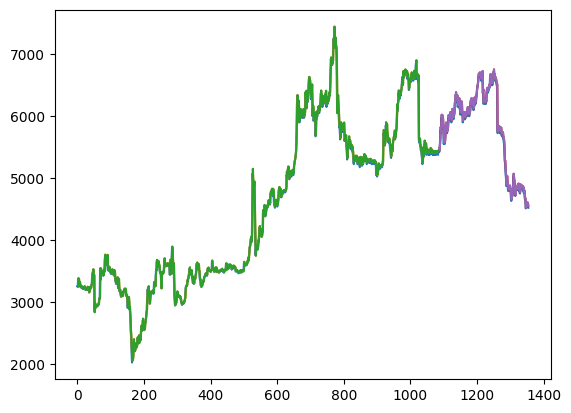

In [ ]:
look_back=2
# shift train predictions for plotting
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2):len(df), :] = testPredict
# plot baseline and predictions
plt.plot(df[['close']])
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [ ]:
prediksi_train = pd.DataFrame(trainPredict)
prediksi_train['Tanggal'] = df.loc[look_back : train_size - 1, 'date'].values
prediksi_train.set_index('Tanggal', inplace=True)

In [ ]:
prediksi_test = pd.DataFrame(testPredict)
prediksi_test['Tanggal'] = df.loc[train_size + look_back : len(df1) - 1, 'date'].values
prediksi_test.set_index('Tanggal', inplace=True)

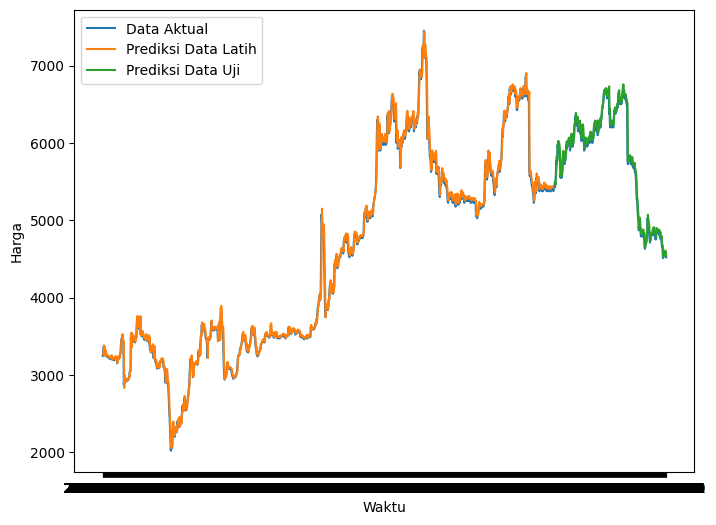

In [ ]:
# Plot data historis dan hasil prediksi
plt.figure(figsize=(8, 6))
plt.plot(ts_df.index, ts_df['close'], label='Data Aktual')
plt.plot(prediksi_train.index, prediksi_train[0], label='Prediksi Data Latih')
plt.plot(prediksi_test.index, prediksi_test[0], label='Prediksi Data Uji')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.legend()
plt.show()

## Cek ACF Residu

In [ ]:
residu5 = y_train - trainPredict

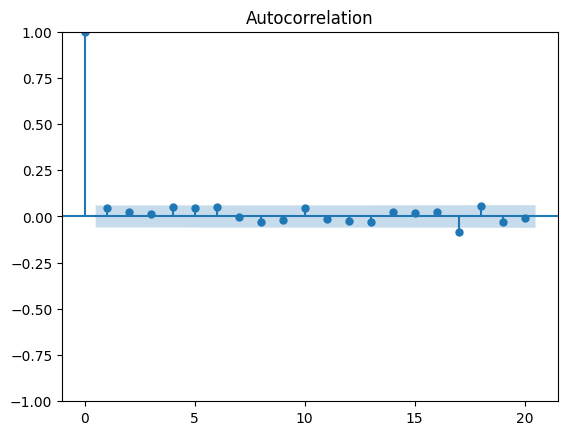

In [ ]:
# Plot ACF
import statsmodels.api as sm

sm.graphics.tsa.plot_acf(residu5, lags=20)
plt.show()

In [ ]:
# Use lags=[20] and set return_df=True to get the results in a DataFrame. Print the resulting DataFrame.
ljungbox_results_p = sm.stats.acorr_ljungbox(residu5, lags=[20], return_df=True)
print("Ljung-Box Test Results for Percobaan Residuals:")
print(ljungbox_results_p)

Ljung-Box Test Results for Percobaan Residuals:
      lb_stat  lb_pvalue
20  31.045203   0.054597


# Forecasting Kombinasi

In [ ]:
look_back = best_lookback # Ensure look_back matches the best_lookback from tuning

min_max_scaler.fit(train)

# Lakukan praproses data input jika diperlukan
df_scale = min_max_scaler.transform(df1)

# Ambil satu data terakhir dari dataset
input_data = df_scale[-look_back:]

# Buat DataFrame untuk menyimpan hasil prediksi
result_df = pd.DataFrame(columns=['Prediksi'])

# Iterasi untuk 12 bulan ke depan
for _ in range(30):

    # Lakukan prediksi
    predicted_value = modela.predict(input_data.reshape(1, -1))

    # Invers transformasi untuk mengembalikan ke skala asli
    predicted_value_original_scale = min_max_scaler.inverse_transform(predicted_value.reshape(-1, 1))

    # Simpan hasil prediksi ke DataFrame
    result_df = pd.concat([result_df, pd.DataFrame({'Prediksi': [predicted_value_original_scale[0, 0]]})], ignore_index=True)

    # Gunakan hasil prediksi sebagai input untuk prediksi berikutnya
    input_data = np.append(input_data[1:], predicted_value)

# Tampilkan atau simpan DataFrame sesuai kebutuhan Anda
print(result_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


/tmp/ipython-input-1732732885.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, pd.DataFrame({'Prediksi': [predicted_value_original_scale[0, 0]]})], ignore_index=True)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━

In [ ]:
last_date = pd.to_datetime(df['date'].iloc[-1])
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=45) # Generate enough dates to pick 30 non-weekends

# Filter out weekends
forecast_dates = forecast_dates[forecast_dates.dayofweek < 5] # Monday=0, Sunday=6

# Take only the first 30 dates
forecast_dates = forecast_dates[:30]

# Assign the generated dates to the result_df
result_df['Tanggal'] = forecast_dates.values

# Set 'Tanggal' as index for better plotting and display
result_df.set_index('Tanggal', inplace=True)

print(result_df)


               Prediksi
Tanggal                
2025-02-24  4544.000000
2025-02-25  4571.476074
2025-02-26  4599.593750
2025-02-27  4628.093750
2025-02-28  4656.956055
2025-03-03  4686.183105
2025-03-04  4715.779297
2025-03-05  4745.749023
2025-03-06  4776.097656
2025-03-07  4806.828613
2025-03-10  4837.948242
2025-03-11  4869.460938
2025-03-12  4901.371582
2025-03-13  4933.685059
2025-03-14  4966.406250
2025-03-17  4999.541016
2025-03-18  5033.093750
2025-03-19  5067.070312
2025-03-20  5101.476562
2025-03-21  5136.316406
2025-03-24  5171.596680
2025-03-25  5207.322266
2025-03-26  5243.499512
2025-03-27  5280.133301
2025-03-28  5317.229980
2025-03-31  5354.794434
2025-04-01  5392.833496
2025-04-02  5431.353027
2025-04-03  5470.358398
2025-04-04  5509.856934


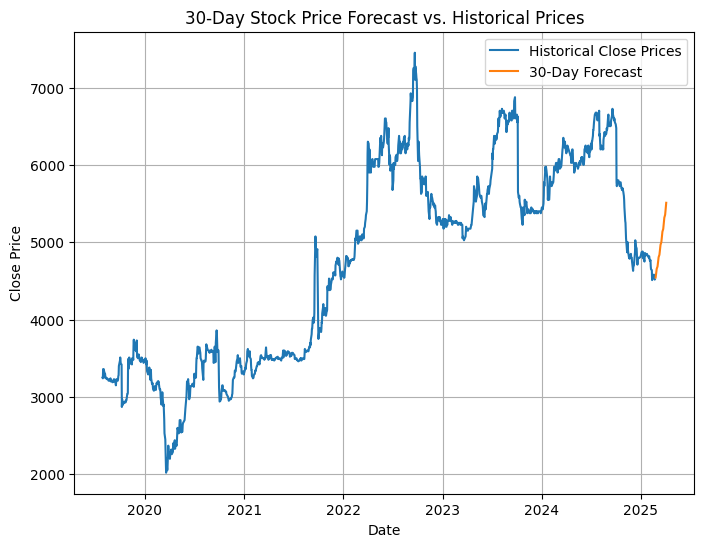

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Convert ts_df.index to datetime objects to ensure compatibility with plotting dates
plt.plot(pd.to_datetime(ts_df.index), ts_df['close'], label='Historical Close Prices')
plt.plot(result_df.index, result_df['Prediksi'], label='30-Day Forecast')
plt.title('30-Day Stock Price Forecast vs. Historical Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Menyimpan prediksi training ke file Excel
prediksi_train.to_excel('[Fix] training relu - INDF.xlsx', index=False)

In [ ]:
# Menyimpan prediksi testing ke file Excel
prediksi_test.to_excel('[Fix] testing relu - INDF.xlsx', index=False)

In [ ]:
# Menyimpan hasil forecast 30 hari ke file Excel
result_df.to_excel('[Fix] prediksi relu - INDF.xlsx', index=False)